# Data Wrangling: Laptop Prices

Cleaning the laptop dataset: finding and filling missing values, fixing types, converting units, normalizing CPU frequency, binning prices into categories and one-hot encoding screen type.

*Lab from IBM's **Data Analysis with Python** course (Coursera), documented in my own words.*

**Skills:** missing-value strategies, `astype`, unit conversion, normalization, `pd.cut()`, `pd.get_dummies()`

## Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

In [4]:
file_name = file_path  # read straight from the URL

In [5]:
df = pd.read_csv(file_name, header=0)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 22.4+ KB
None


In [8]:
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [9]:
df[['Screen_Size_cm']] = np.round(df[['Screen_Size_cm']],1)
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.6,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.6,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.6,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.8,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.6,1.8,8,256,1.91,837


## Find missing values

In [10]:
missing_data = df.isnull()
display(missing_data.head())
for column in missing_data.columns:
    print(missing_data[column].value_counts())
    print("")

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False


Unnamed: 0
False    238
Name: count, dtype: int64

Manufacturer
False    238
Name: count, dtype: int64

Category
False    238
Name: count, dtype: int64

Screen
False    238
Name: count, dtype: int64

GPU
False    238
Name: count, dtype: int64

OS
False    238
Name: count, dtype: int64

CPU_core
False    238
Name: count, dtype: int64

Screen_Size_cm
False    234
True       4
Name: count, dtype: int64

CPU_frequency
False    238
Name: count, dtype: int64

RAM_GB
False    238
Name: count, dtype: int64

Storage_GB_SSD
False    238
Name: count, dtype: int64

Weight_kg
False    233
True       5
Name: count, dtype: int64

Price
False    238
Name: count, dtype: int64



## Fill missing values

In [12]:
df["Weight_kg"] = df["Weight_kg"].fillna(df["Weight_kg"].mean())

### Replace with the most frequent value

In [13]:
df["Screen_Size_cm"] = df["Screen_Size_cm"].fillna(df["Screen_Size_cm"].value_counts().idxmax())

## Fix data types

In [14]:
df[["Weight_kg", "Screen_Size_cm"]] = df[["Weight_kg", "Screen_Size_cm"]].astype("float")

## Standardize units (kg → lbs, cm → inches)

In [15]:
# Data Standardization: converting weight/size from kg/cm to lbs/inch:
df["Weight_kg"] = df["Weight_kg"]*2.20462
df["Screen_Size_cm"] = df["Screen_Size_cm"]/2.54
# Data Standardization: renaming column names:
df= df.rename(columns={"Weight_kg":"Weight_lbs", "Screen_Size_cm":"Screen_Size_in"})
# Displaying head:
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_in,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_lbs,Price
0,0,Acer,4,IPS Panel,2,1,5,14.015748,1.6,8,256,3.527392,978
1,1,Dell,3,Full HD,1,1,3,15.590551,2.0,4,256,4.850164,634
2,2,Dell,3,Full HD,1,1,7,15.590551,2.7,8,256,4.850164,946
3,3,Dell,4,IPS Panel,2,1,5,13.307087,1.6,8,128,2.689636,1244
4,4,HP,4,Full HD,2,1,7,15.590551,1.8,8,256,4.210824,837


### Data Normalization

In [21]:
df["CPU_frequency"] = df["CPU_frequency"]/df["CPU_frequency"].max()

In [23]:
df = df.drop(columns="Unnamed: 0")
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_in,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_lbs,Price
0,Acer,4,IPS Panel,2,1,5,14.015748,0.551724,8,256,3.527392,978
1,Dell,3,Full HD,1,1,3,15.590551,0.689655,4,256,4.850164,634
2,Dell,3,Full HD,1,1,7,15.590551,0.931034,8,256,4.850164,946
3,Dell,4,IPS Panel,2,1,5,13.307087,0.551724,8,128,2.689636,1244
4,HP,4,Full HD,2,1,7,15.590551,0.620690,8,256,4.210824,837


## Bin prices into categories

In [26]:
bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)
names = ["Low", "Med", "High"]
df["Price-category"] = pd.cut(df["Price"], bins, labels=names, include_lowest=True)

In [27]:
df["Price-category"].value_counts()

Price-category
Low     160
Med      72
High      6
Name: count, dtype: int64

Text(0.5, 1.0, 'Laptop Price Categories')

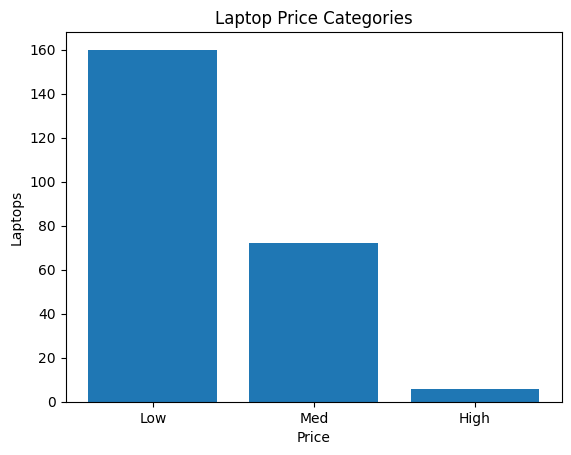

In [34]:
plt.bar(names, df["Price-category"].value_counts().sort_index())
plt.xlabel("Price")
plt.ylabel("Laptops")
plt.title("Laptop Price Categories")

## Indicator variables for screen type

In [37]:
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_in,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_lbs,Price,Price-category
0,Acer,4,IPS Panel,2,1,5,14.015748,0.551724,8,256,3.527392,978,Low
1,Dell,3,Full HD,1,1,3,15.590551,0.689655,4,256,4.850164,634,Low
2,Dell,3,Full HD,1,1,7,15.590551,0.931034,8,256,4.850164,946,Low
3,Dell,4,IPS Panel,2,1,5,13.307087,0.551724,8,128,2.689636,1244,Low
4,HP,4,Full HD,2,1,7,15.590551,0.620690,8,256,4.210824,837,Low


In [41]:
screen_dummies = pd.get_dummies(df["Screen"])
screen_dummies = screen_dummies.rename(columns={"IPS Panel":"Screen-IPS_panel", "Full HD":"Screen-Full HD"})
df = pd.concat([df, screen_dummies], axis=1)
# dropping Screen column
df = df.drop(columns="Screen")

In [43]:
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_in,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_lbs,Price,Price-category,Screen-Full HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.015748,0.551724,8,256,3.527392,978,Low,False,True
1,Dell,3,1,1,3,15.590551,0.689655,4,256,4.850164,634,Low,True,False
2,Dell,3,1,1,7,15.590551,0.931034,8,256,4.850164,946,Low,True,False
3,Dell,4,2,1,5,13.307087,0.551724,8,128,2.689636,1244,Low,False,True
4,HP,4,2,1,7,15.590551,0.620690,8,256,4.210824,837,Low,True,False


## What I took away

- `Screen_Size_cm` is a float but holds only 9 distinct values, so it's categorical and gets the most frequent value, not the mean.
- `Weight_kg` has 77 distinct values with real gaps between them, so it's continuous and gets the mean.
- `value_counts()` sorts by count, so `.sort_index()` is needed before plotting bins in order.